In [1]:
import pandas as pd
import os
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.backends.backend_pdf import PdfPages

In [2]:
def excel_to_csvs(filepath, output_dir=None):
    # Create output directory if not provided
    if output_dir is None:
        output_dir = os.path.splitext(filepath)[0] + "_csvs"
    os.makedirs(output_dir, exist_ok=True)

    # Load Excel file
    excel_file = pd.ExcelFile(filepath)
    
    # Iterate through each sheet and save as CSV
    for sheet_name in excel_file.sheet_names:
        df = pd.read_excel(filepath, sheet_name=sheet_name)
        csv_filename = f"{sheet_name}.csv"
        csv_path = os.path.join(output_dir, csv_filename)
        df.to_csv(csv_path, index=False)
        print(f"Saved: {csv_path}")

# Example usage
excel_to_csvs("/Users/jayashri/Desktop/ManualGranuleAnalysis.xlsx")

Saved: /Users/jayashri/Desktop/ManualGranuleAnalysis_csvs/25529004Events.csv
Saved: /Users/jayashri/Desktop/ManualGranuleAnalysis_csvs/25603002Events.csv
Saved: /Users/jayashri/Desktop/ManualGranuleAnalysis_csvs/25603010Events.csv
Saved: /Users/jayashri/Desktop/ManualGranuleAnalysis_csvs/25603006Events.csv
Saved: /Users/jayashri/Desktop/ManualGranuleAnalysis_csvs/25609007Events.csv
Saved: /Users/jayashri/Desktop/ManualGranuleAnalysis_csvs/25609011Events.csv
Saved: /Users/jayashri/Desktop/ManualGranuleAnalysis_csvs/25609016Events.csv
Saved: /Users/jayashri/Desktop/ManualGranuleAnalysis_csvs/25609003Events550s.csv
Saved: /Users/jayashri/Desktop/ManualGranuleAnalysis_csvs/25610006Events1050s.csv
Saved: /Users/jayashri/Desktop/ManualGranuleAnalysis_csvs/25522003Events1050s.csv
Saved: /Users/jayashri/Desktop/ManualGranuleAnalysis_csvs/25612002Events800s.csv


In [5]:
def plot_all_metrics_per_sweep(csv_path, trace_column='trace', time_column='event start time (ms)', sweep_duration=30):
    # Load data
    df = pd.read_csv(csv_path)

    # Ensure required columns exist
    if trace_column not in df.columns:
        raise ValueError(f"'{trace_column}' column not found in the CSV.")
    if time_column not in df.columns:
        raise ValueError(f"'{time_column}' column not found in the CSV.")

    # Convert event time from ms to seconds and calculate sweep number
    df['sweep'] = (df[time_column] / 1000 // sweep_duration).astype(int)

    # Convert all columns to numeric where possible, coerce errors
    numeric_df = df.apply(pd.to_numeric, errors='coerce')
    numeric_df[trace_column] = df[trace_column]  # Restore 'trace' if converted to NaN

    # Identify columns to plot (excluding trace, time, and sweep columns)
    columns_to_plot = [
        col for col in numeric_df.columns 
        if col not in [trace_column, time_column, 'sweep'] and numeric_df[col].dtype != 'O'
    ]

    # Group by calculated sweep number
    grouped = numeric_df.groupby('sweep')

    for col in columns_to_plot:
        means = grouped[col].mean()
        sems = grouped[col].sem()

        plt.figure(figsize=(10, 6))
        plt.errorbar(means.index, means.values, yerr=sems.values, fmt='o', capsize=5)
        plt.title(f'{col} per Sweep (Mean ± SEM)')
        plt.xlabel('Sweep Number')
        plt.ylabel(col)
        plt.grid(True)
        plt.tight_layout()
        plt.show()

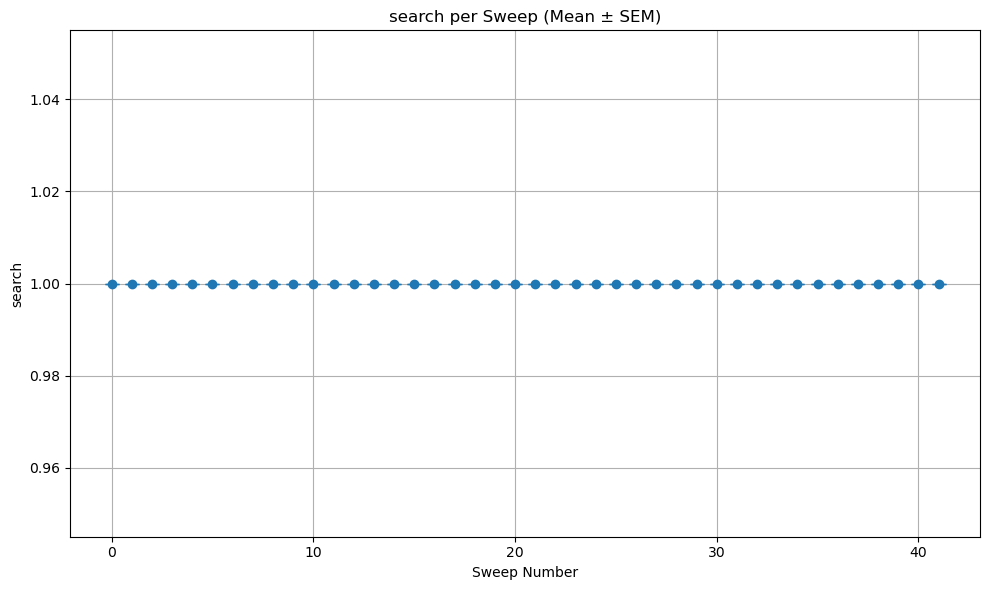

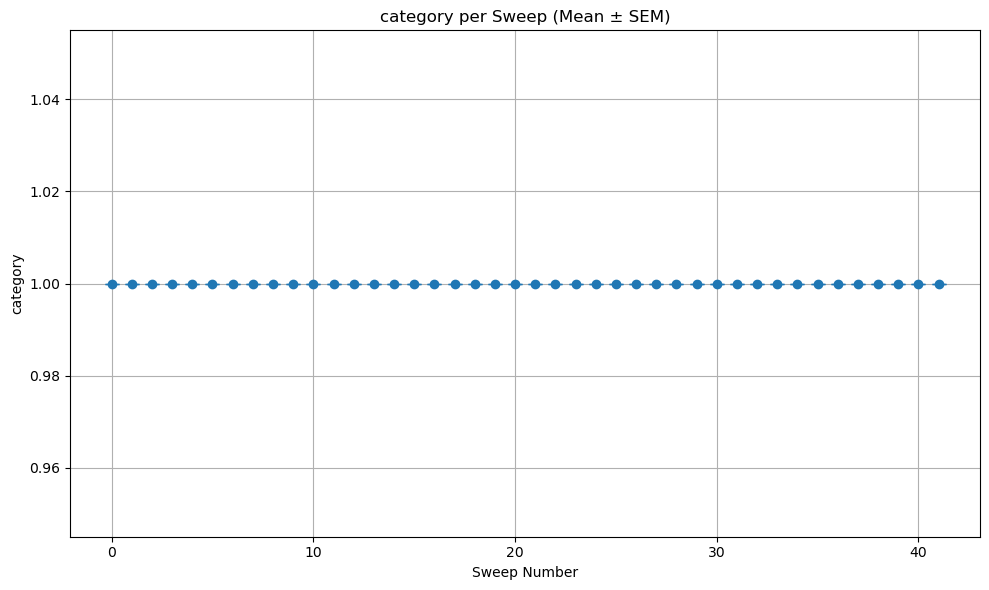

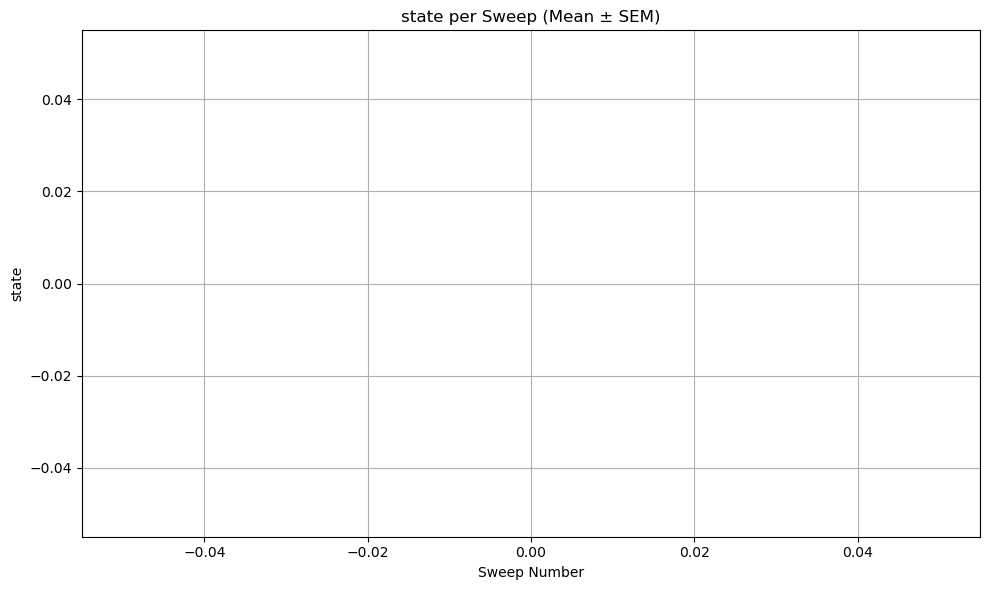

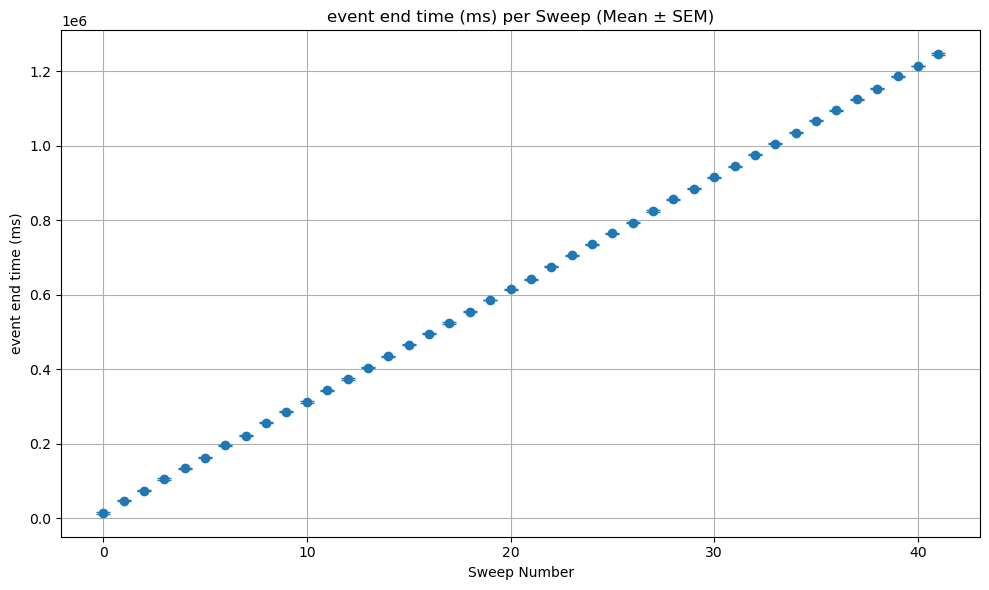

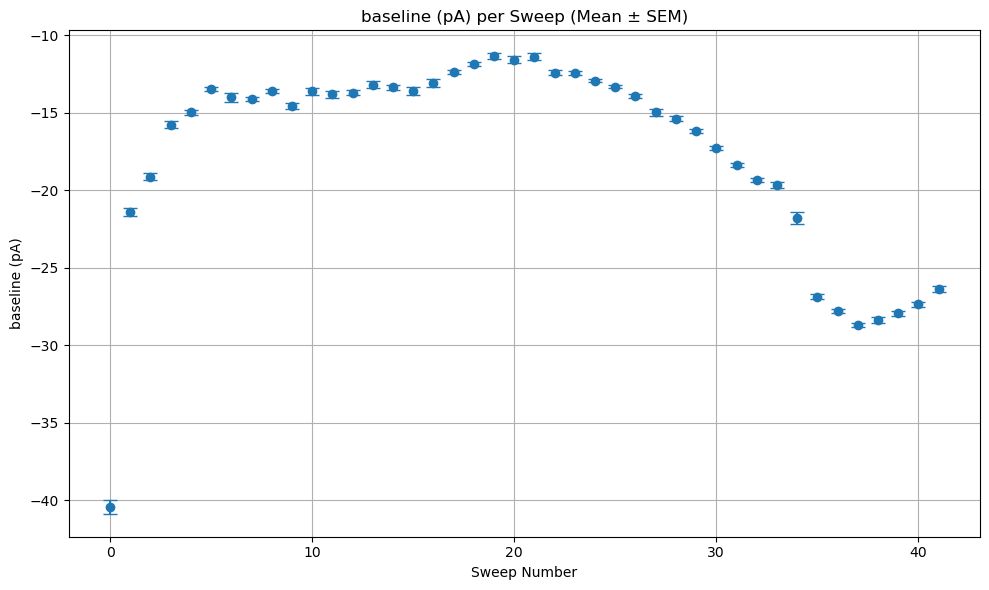

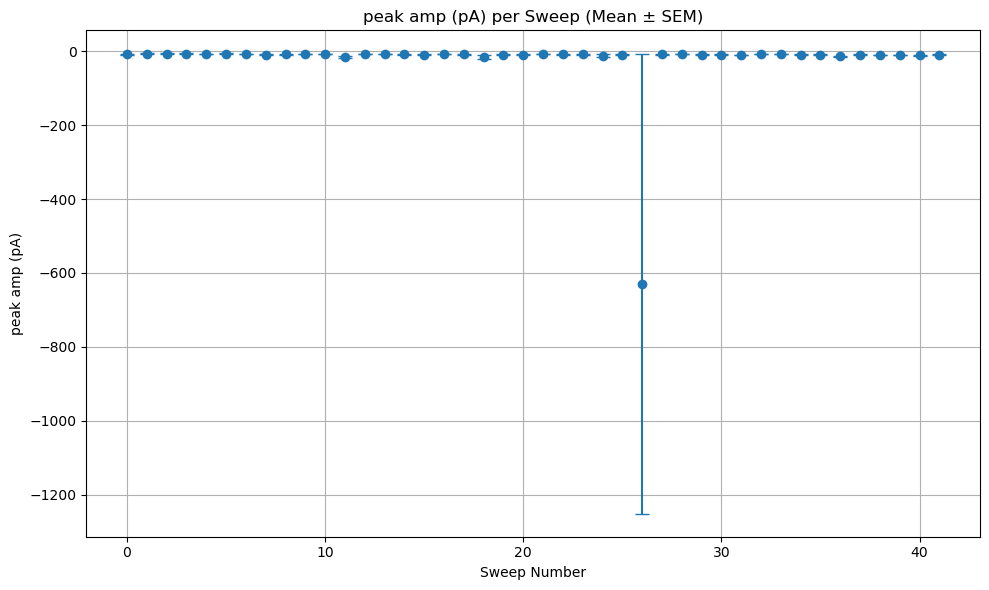

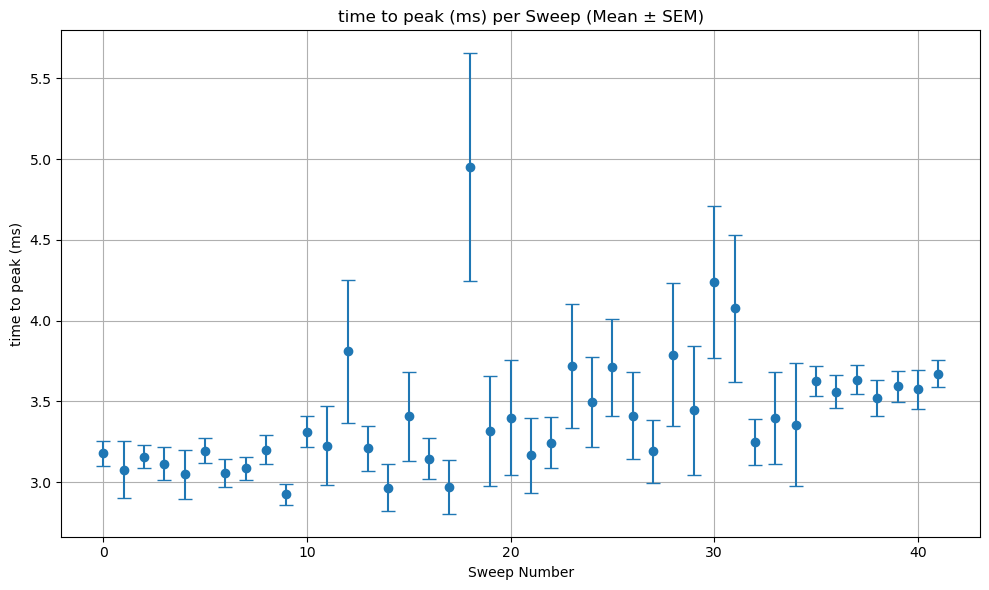

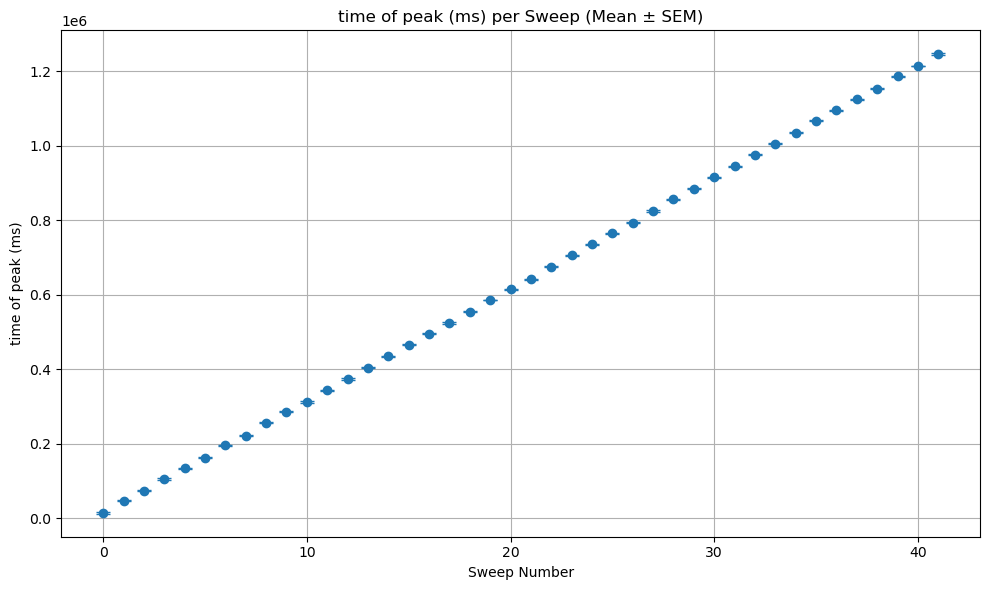

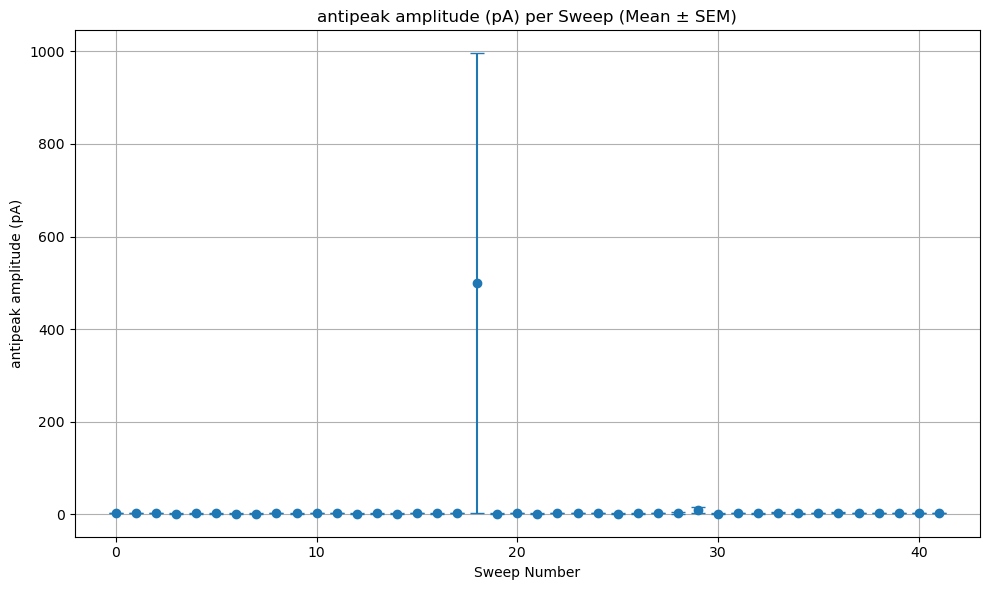

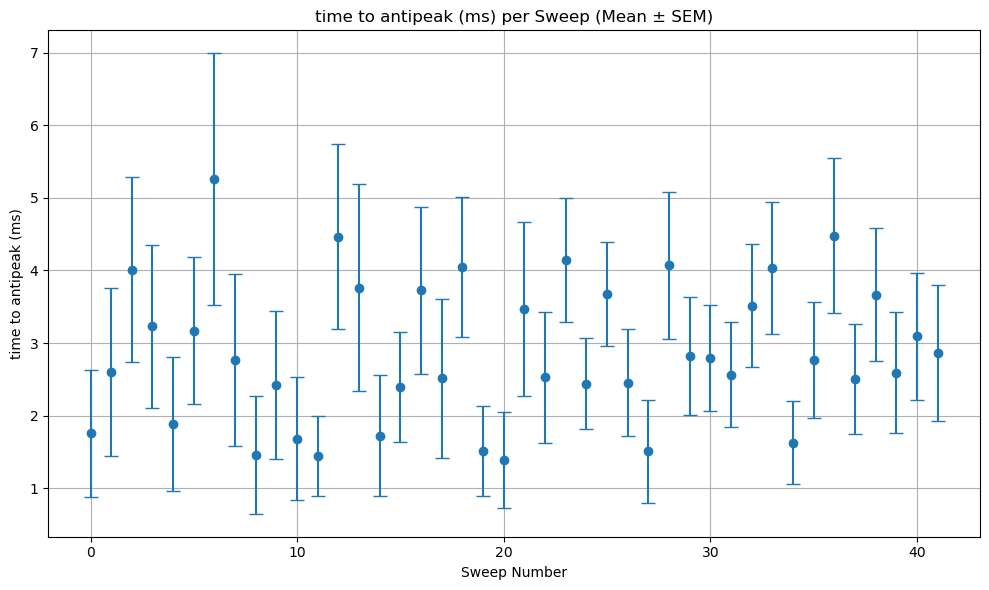

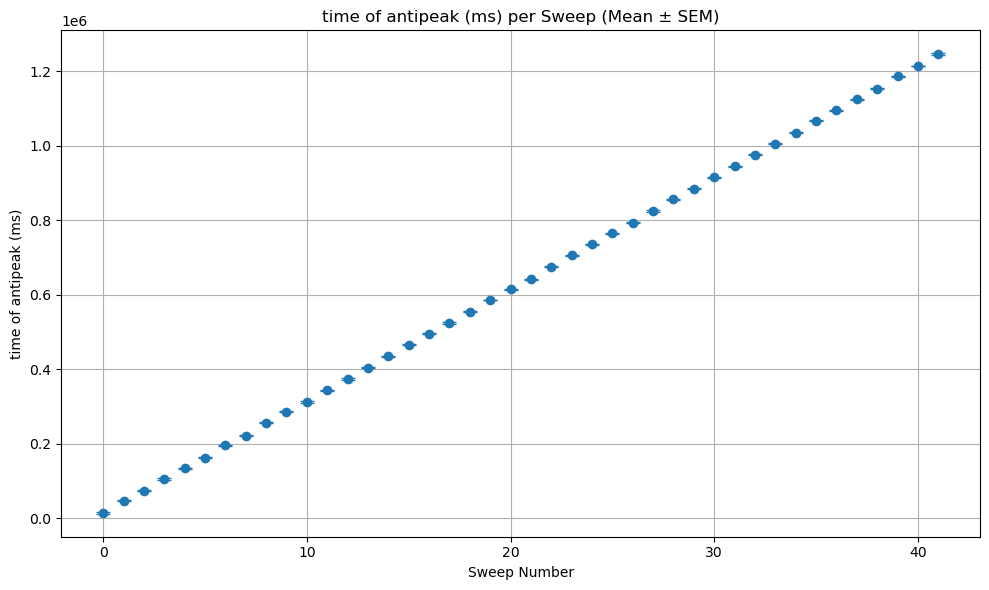

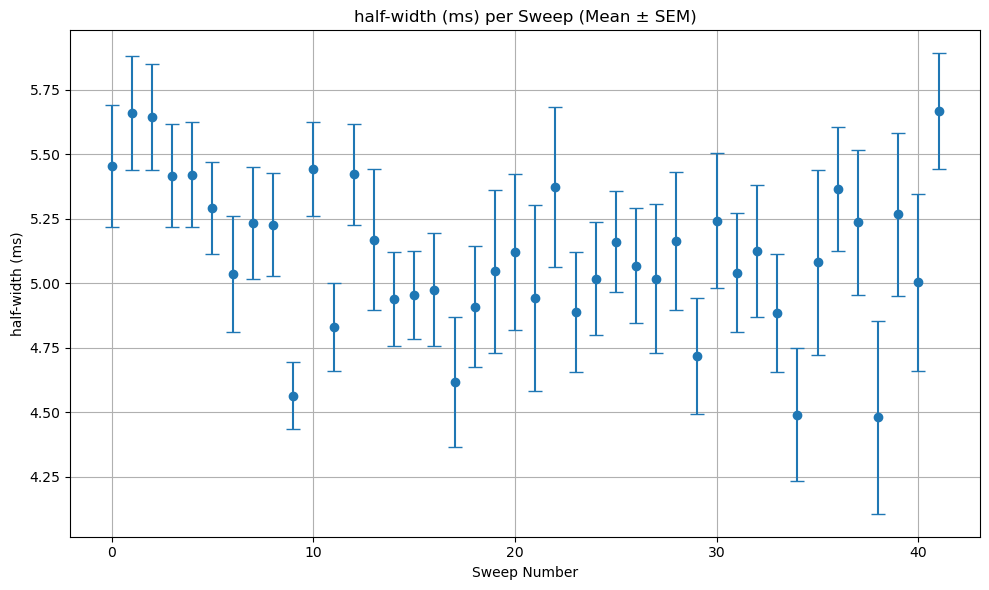

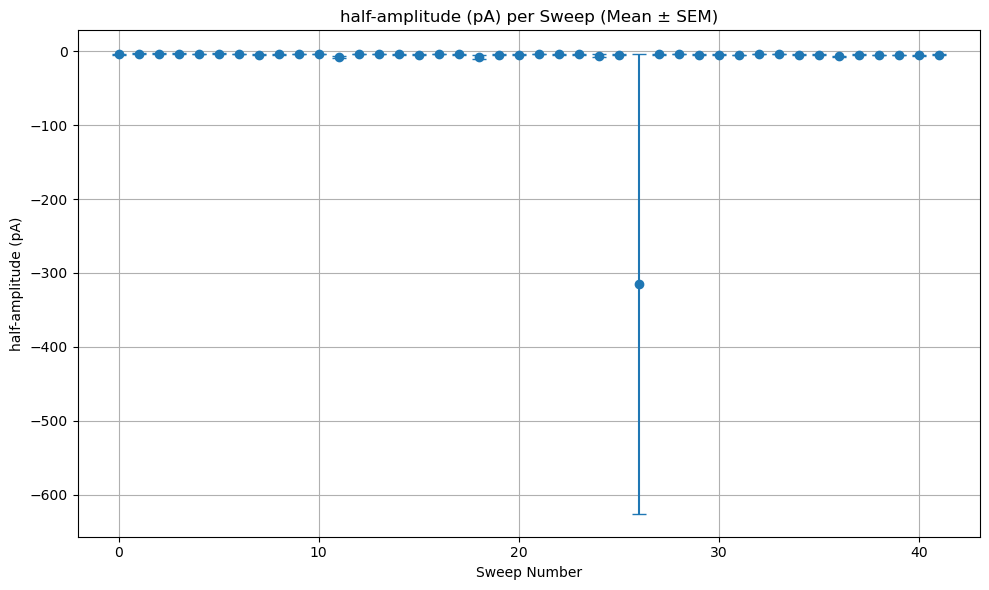

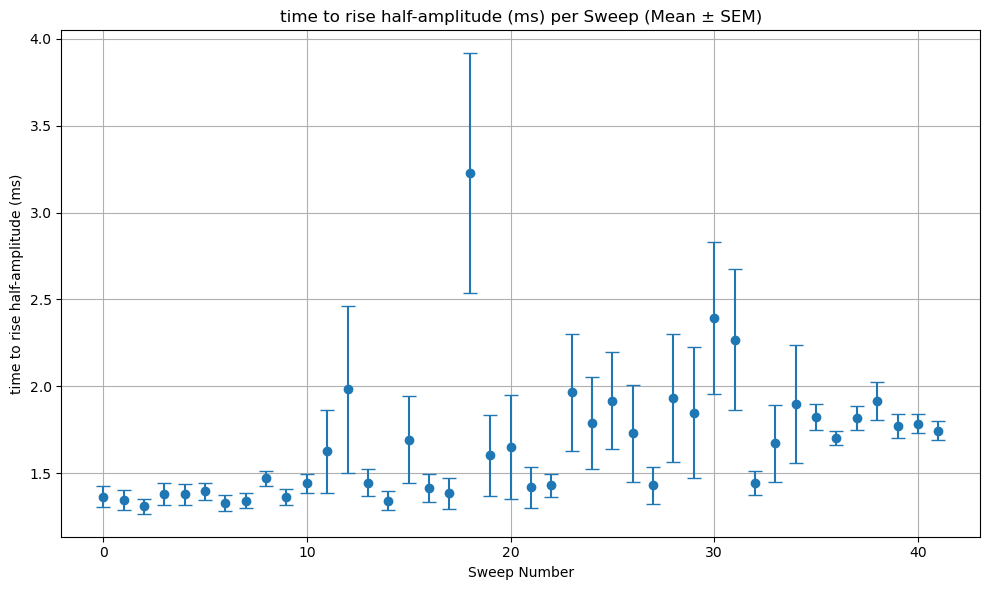

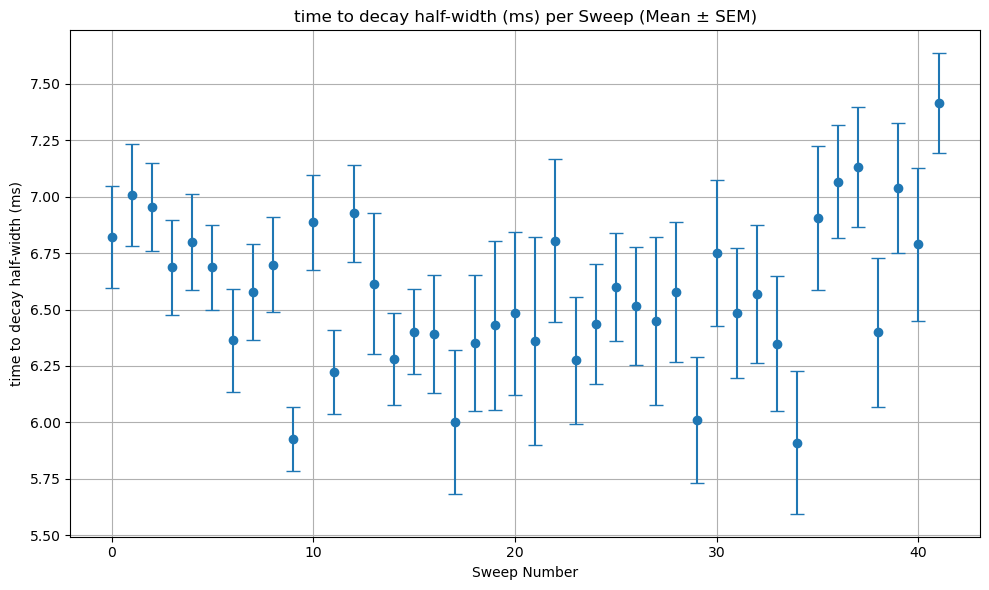

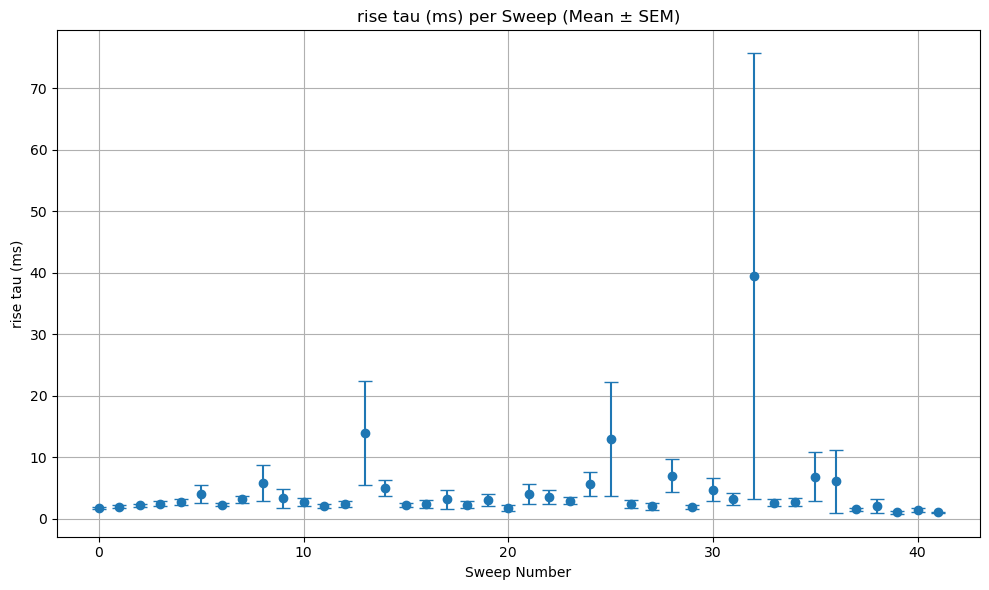

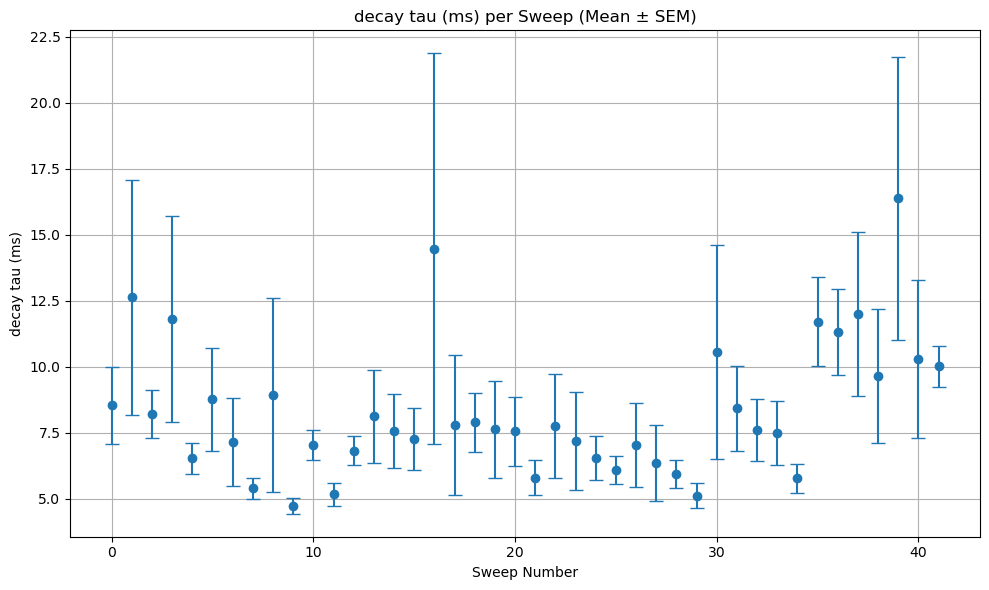

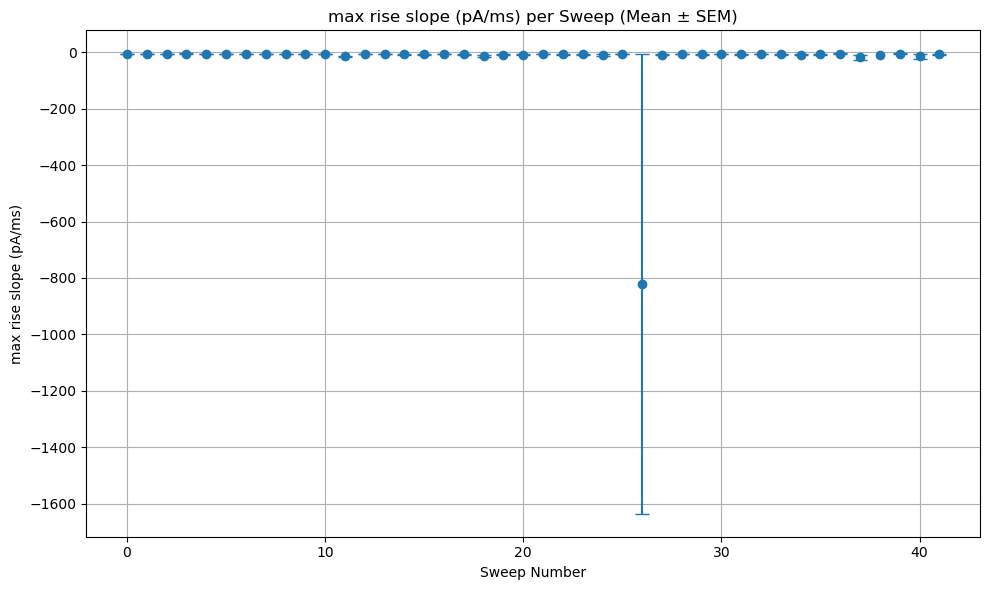

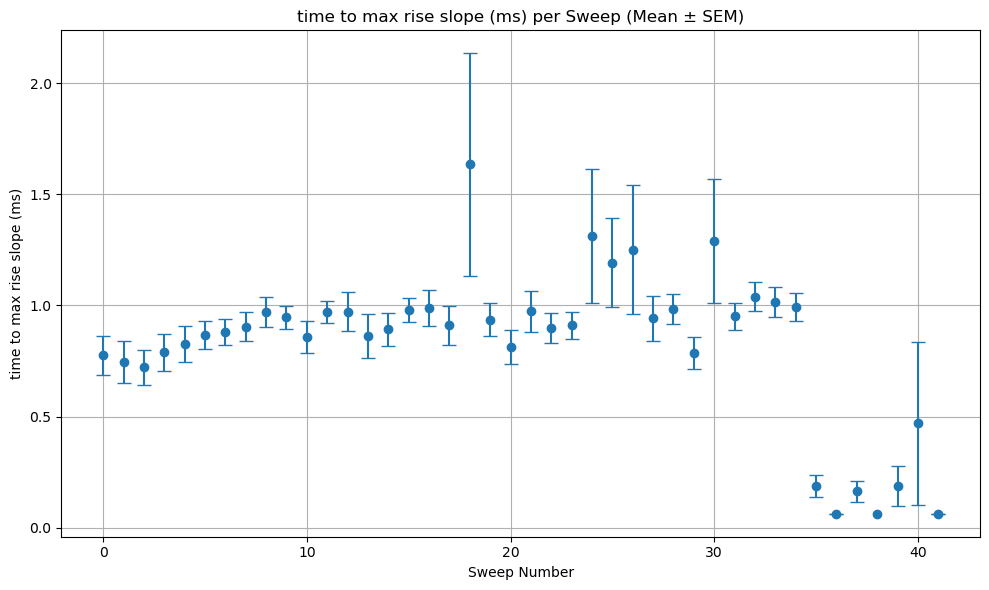

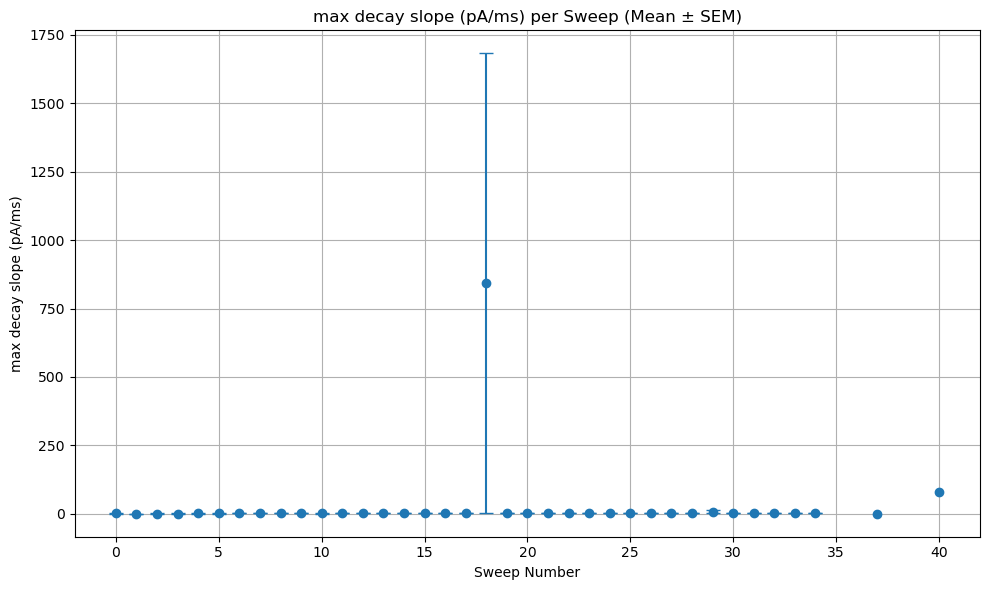

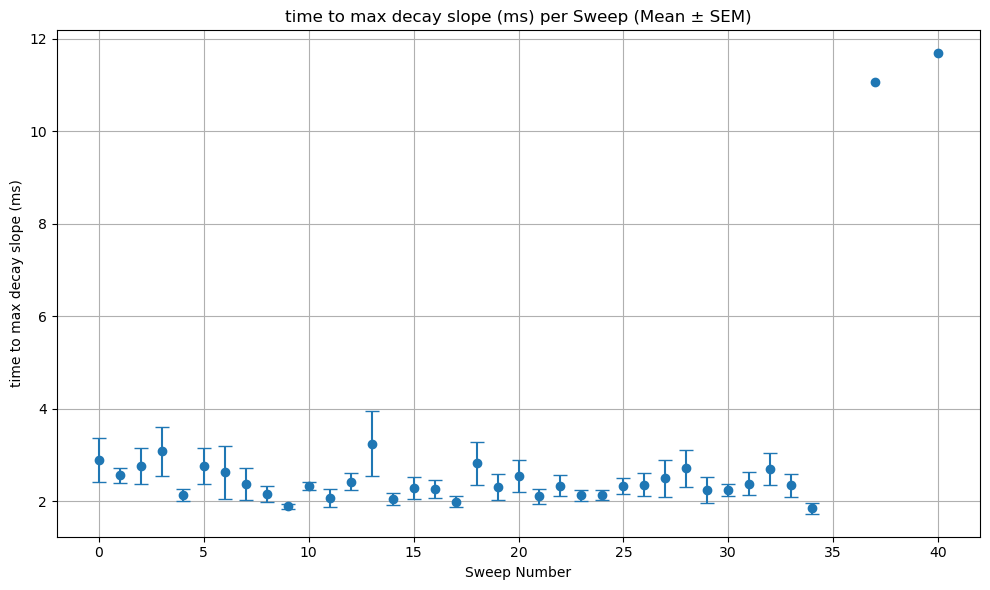

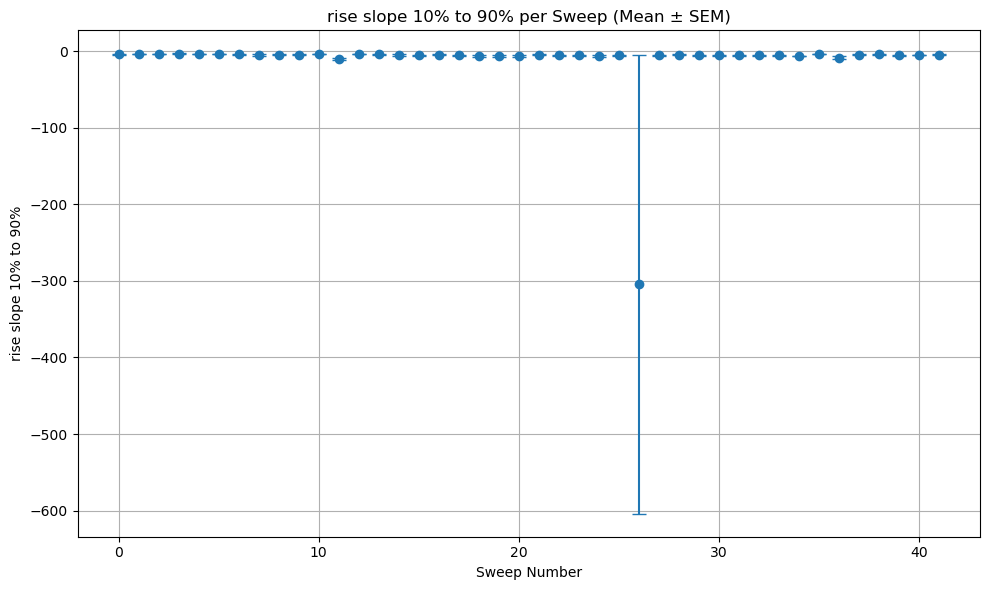

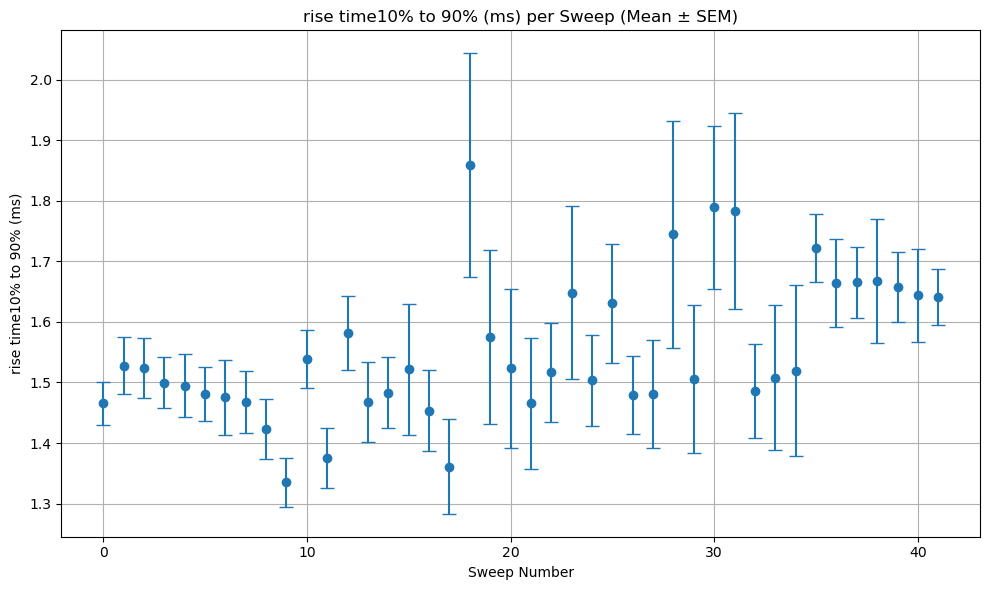

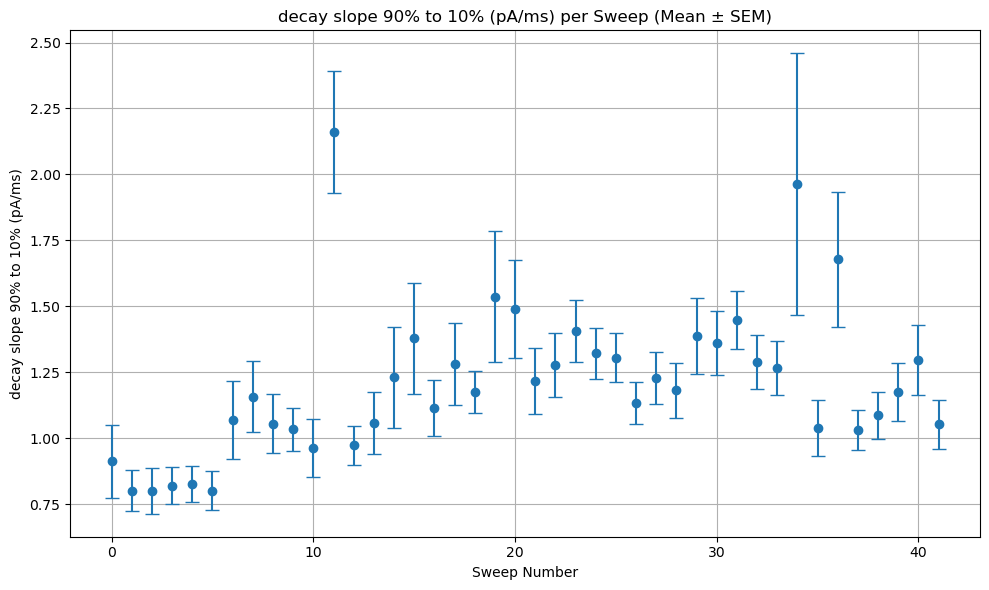

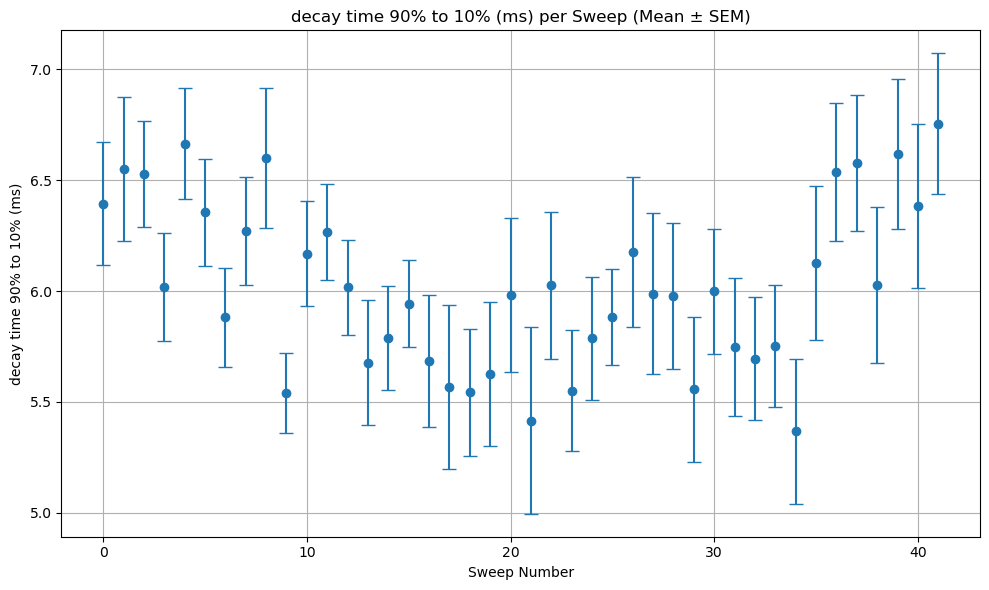

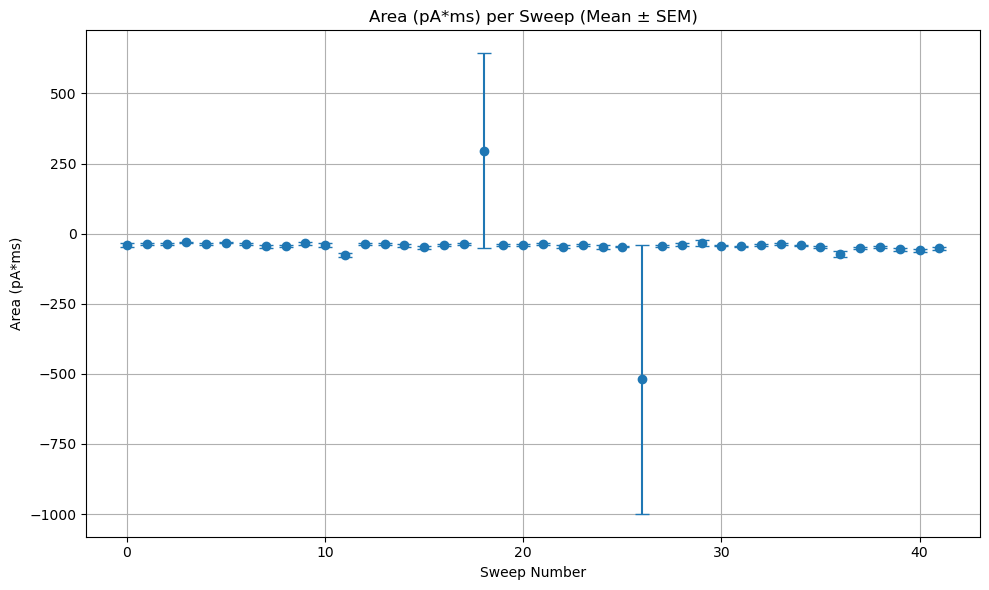

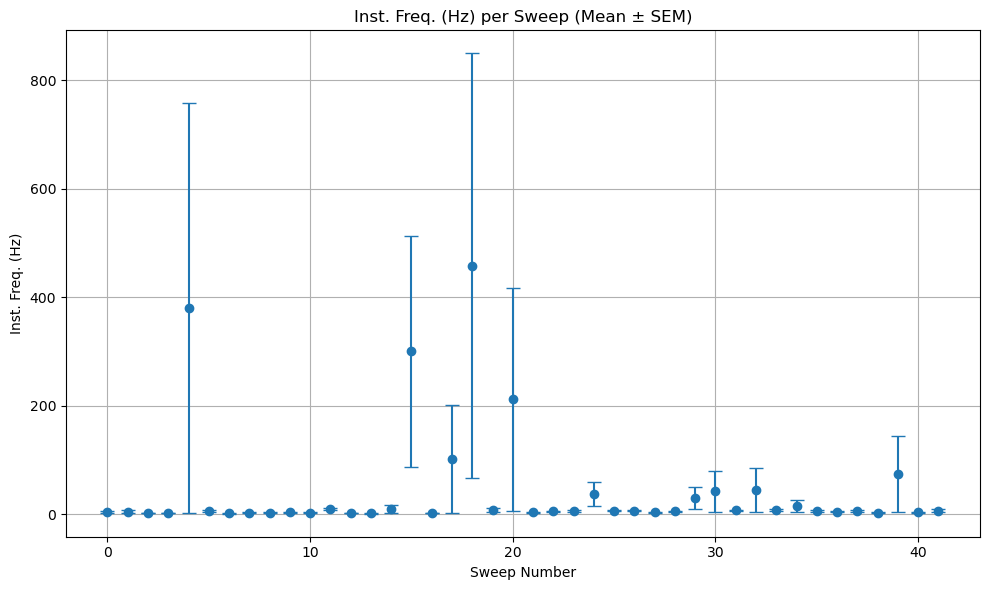

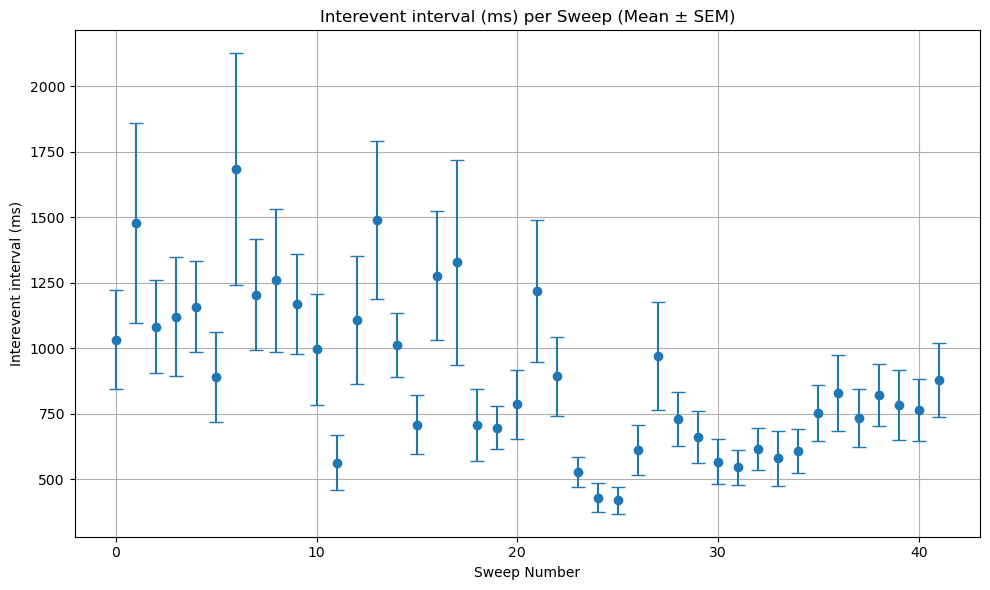

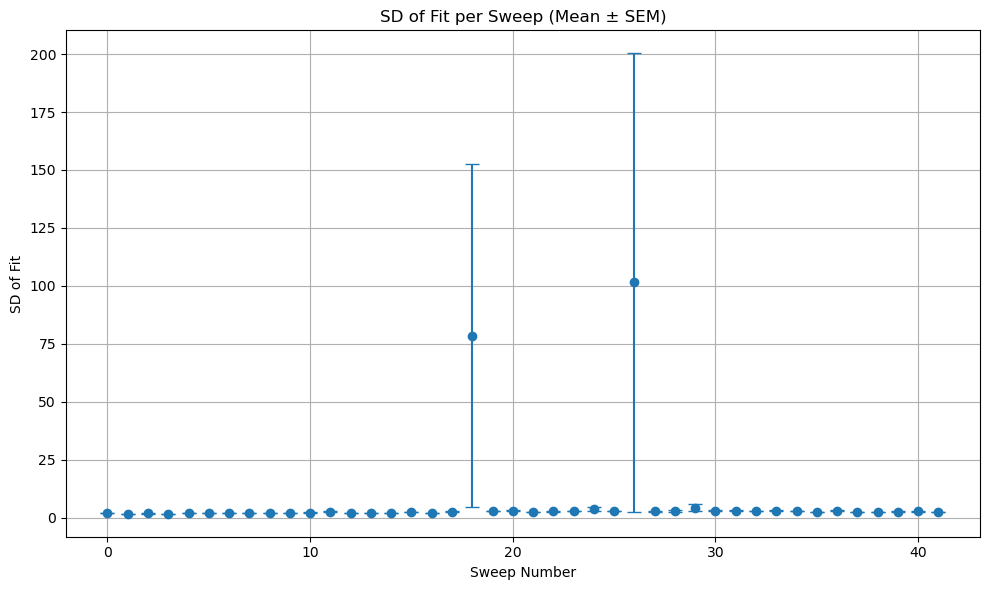

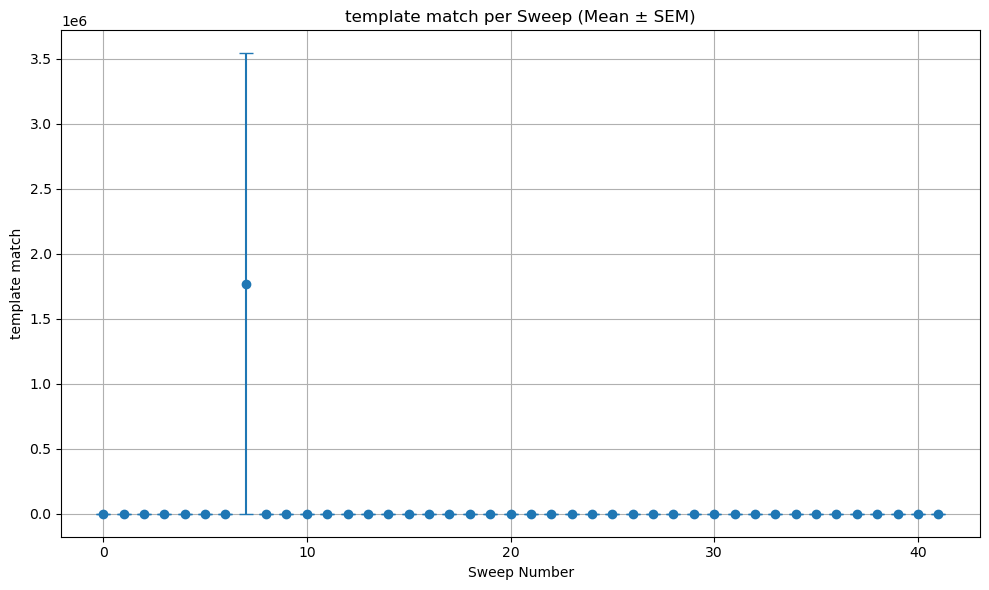

In [14]:
plot_all_metrics_per_sweep("/Users/jayashri/Desktop/ManualGranuleAnalysis_csvs/25603002Events.csv")

In [27]:
def plot_drug_application_effects_with_points(
    csv_path, 
    start_sweep, 
    end_sweep, 
    time_column='event start time (ms)', 
    sweep_duration=30
):
    # Columns to plot
    target_columns = ['peak amp (pA)', 'Interevent interval (ms)']

    # Load and convert
    df = pd.read_csv(csv_path)

    # Check for required columns
    missing = [col for col in [time_column] + target_columns if col not in df.columns]
    if missing:
        raise ValueError(f"Missing column(s) in CSV: {', '.join(missing)}")

    # Calculate sweep number
    df['sweep'] = (df[time_column] / 1000 // sweep_duration).astype(int)

    # Convert to numeric
    numeric_df = df.apply(pd.to_numeric, errors='coerce')

    # Label drug application period
    def label_period(sweep_num):
        if sweep_num < start_sweep:
            return "Before"
        elif sweep_num > end_sweep:
            return "After"
        elif start_sweep < sweep_num < end_sweep:
            return "During"
        else:
            return None  # exclude exact boundaries

    numeric_df['period'] = numeric_df['sweep'].apply(label_period)
    filtered_df = numeric_df[numeric_df['period'].notna()]

    # Generate plots for each target column
    for col in target_columns:
        plt.figure(figsize=(8, 5))

        # Scatter plot of individual points
        sns.stripplot(data=filtered_df, x='period', y=col, jitter=True, alpha=0.6)

        # Overlay mean ± SEM
        means = filtered_df.groupby('period')[col].mean()
        sems = filtered_df.groupby('period')[col].sem()
        plt.errorbar(x=means.index, y=means.values, yerr=sems.values, fmt='o', color='black', capsize=5, label='Mean ± SEM')

        plt.title(f'{col} by Drug Application Period')
        plt.ylabel(col)
        plt.xlabel('Condition')
        plt.grid(True, axis='y', linestyle='--', alpha=0.5)
        plt.tight_layout()
        plt.legend()
        plt.show()

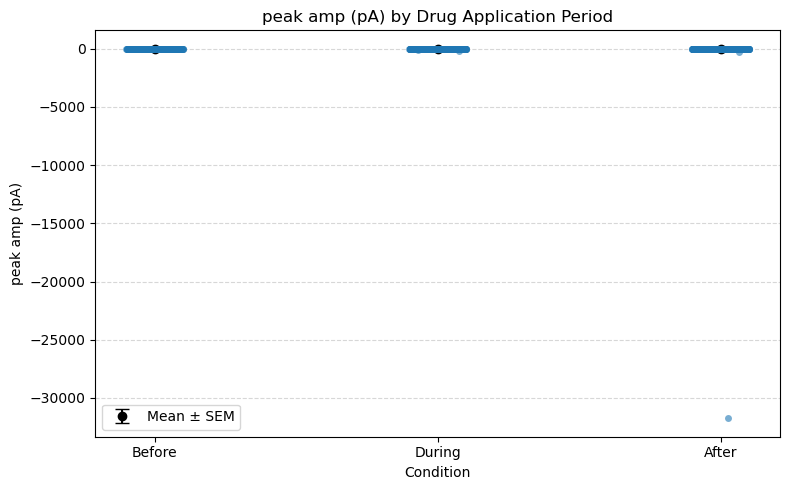

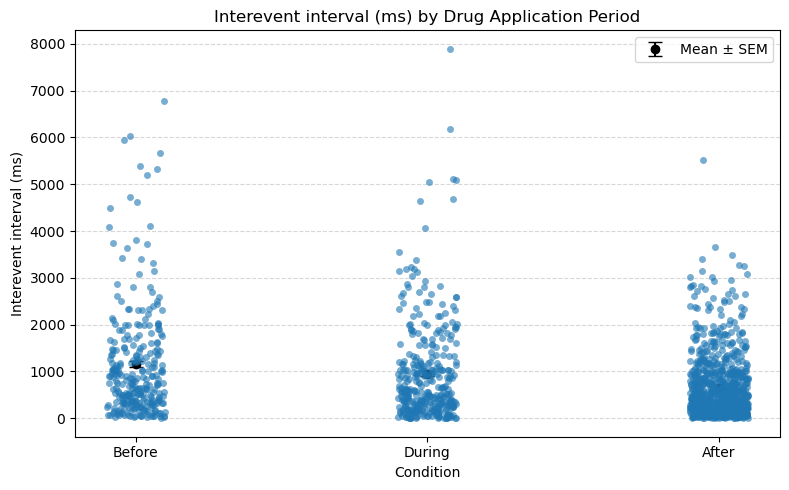

In [29]:
plot_drug_application_effects_with_points("/Users/jayashri/Desktop/ManualGranuleAnalysis_csvs/25603002Events.csv", start_sweep=11, end_sweep=23)

In [53]:
def plot_and_save_all_measurements_from_directory(
    folder_path,
    start_sweep,
    end_sweep,
    time_column='event start time (ms)',
    sweep_duration=30,
    output_folder=None
):
    if output_folder is None:
        output_folder = os.path.join(folder_path, "drug_analysis_pngs")
    os.makedirs(output_folder, exist_ok=True)

    csv_files = [f for f in os.listdir(folder_path) if f.lower().endswith('.csv')]

    for csv_file in csv_files:
        csv_path = os.path.join(folder_path, csv_file)
        print(f"Processing: {csv_file}")

        try:
            df = pd.read_csv(csv_path)

            # Check for time column
            if time_column not in df.columns:
                raise ValueError(f"Missing required column: {time_column}")

            # Compute sweep from event time
            df['sweep'] = (df[time_column] / 1000 // sweep_duration).astype(int)

            # Convert to numeric
            numeric_df = df.apply(pd.to_numeric, errors='coerce')

            # Label drug application periods
            def label_period(sweep_num):
                if sweep_num < start_sweep:
                    return "Before"
                elif sweep_num > end_sweep:
                    return "After"
                elif start_sweep < sweep_num < end_sweep:
                    return "During"
                else:
                    return None  # exclude exact boundaries

            numeric_df['period'] = numeric_df['sweep'].apply(label_period)
            filtered_df = numeric_df[numeric_df['period'].notna()]

            # Automatically detect measurement columns (numeric and not metadata)
            excluded_cols = {'sweep', time_column, 'period'}
            measurement_cols = [
                col for col in filtered_df.columns
                if col not in excluded_cols and filtered_df[col].dtype != 'O'
            ]

            base_filename = os.path.splitext(csv_file)[0]

            for col in measurement_cols:
                plt.figure(figsize=(8, 5))

                sns.stripplot(data=filtered_df, x='period', y=col, jitter=True, alpha=0.6)

                # Compute y-limits for 95% inclusion
                lower = np.nanpercentile(filtered_df[col], 2.5)
                upper = np.nanpercentile(filtered_df[col], 97.5)
                plt.ylim(lower, upper)

                # Mean ± SEM overlay
                means = filtered_df.groupby('period')[col].mean()
                sems = filtered_df.groupby('period')[col].sem()
                plt.errorbar(x=means.index, y=means.values, yerr=sems.values,
                             fmt='o', color='black', capsize=5, label='Mean ± SEM')

                plt.title(f'{col} by Drug Application Period')
                plt.ylabel(col)
                plt.xlabel('Condition')
                plt.grid(True, axis='y', linestyle='--', alpha=0.5)
                plt.tight_layout()
                plt.legend()

                # Clean filename
                safe_col = col.replace(' ', '_').replace('(', '').replace(')', '').replace('/', '')
                output_filename = f"{base_filename}_{safe_col}.png"
                output_path = os.path.join(output_folder, output_filename)
                plt.savefig(output_path, dpi=300)
                plt.close()

                print(f"Saved: {output_path}")

        except Exception as e:
            print(f"Failed to process {csv_file}: {e}")

Processing: 25603006Events.csv
Saved: /Users/jayashri/Desktop/ManualGranuleAnalysis_csvs/drug_analysis_pngs/25603006Events_trace.png


/var/folders/bz/z94gnqs93496sv93fzsm61880000gn/T/ipykernel_45134/555187315.py:63: UserWarning: Attempting to set identical low and high ylims makes transformation singular; automatically expanding.
  plt.ylim(lower, upper)
/var/folders/bz/z94gnqs93496sv93fzsm61880000gn/T/ipykernel_45134/555187315.py:63: UserWarning: Attempting to set identical low and high ylims makes transformation singular; automatically expanding.
  plt.ylim(lower, upper)


Saved: /Users/jayashri/Desktop/ManualGranuleAnalysis_csvs/drug_analysis_pngs/25603006Events_search.png
Saved: /Users/jayashri/Desktop/ManualGranuleAnalysis_csvs/drug_analysis_pngs/25603006Events_category.png
Failed to process 25603006Events.csv: Axis limits cannot be NaN or Inf
Processing: 25609007Events.csv


/var/folders/bz/z94gnqs93496sv93fzsm61880000gn/T/ipykernel_45134/555187315.py:63: UserWarning: Attempting to set identical low and high ylims makes transformation singular; automatically expanding.
  plt.ylim(lower, upper)
/opt/anaconda3/lib/python3.12/site-packages/numpy/lib/nanfunctions.py:1384: RuntimeWarning: All-NaN slice encountered
  return _nanquantile_unchecked(
/var/folders/bz/z94gnqs93496sv93fzsm61880000gn/T/ipykernel_45134/555187315.py:63: UserWarning: Attempting to set identical low and high ylims makes transformation singular; automatically expanding.
  plt.ylim(lower, upper)


Saved: /Users/jayashri/Desktop/ManualGranuleAnalysis_csvs/drug_analysis_pngs/25609007Events_trace.png
Saved: /Users/jayashri/Desktop/ManualGranuleAnalysis_csvs/drug_analysis_pngs/25609007Events_search.png


...

/var/folders/bz/z94gnqs93496sv93fzsm61880000gn/T/ipykernel_45134/555187315.py:63: UserWarning: Attempting to set identical low and high ylims makes transformation singular; automatically expanding.
  plt.ylim(lower, upper)
/var/folders/bz/z94gnqs93496sv93fzsm61880000gn/T/ipykernel_45134/555187315.py:63: UserWarning: Attempting to set identical low and high ylims makes transformation singular; automatically expanding.
  plt.ylim(lower, upper)


Saved: /Users/jayashri/Desktop/ManualGranuleAnalysis_csvs/drug_analysis_pngs/25610006Events1050s_category.png
Failed to process 25610006Events1050s.csv: Axis limits cannot be NaN or Inf
Processing: 25522003Events1050s.csv
Saved: /Users/jayashri/Desktop/ManualGranuleAnalysis_csvs/drug_analysis_pngs/25522003Events1050s_trace.png


/opt/anaconda3/lib/python3.12/site-packages/numpy/lib/nanfunctions.py:1384: RuntimeWarning: All-NaN slice encountered
  return _nanquantile_unchecked(
/var/folders/bz/z94gnqs93496sv93fzsm61880000gn/T/ipykernel_45134/555187315.py:63: UserWarning: Attempting to set identical low and high ylims makes transformation singular; automatically expanding.
  plt.ylim(lower, upper)
/var/folders/bz/z94gnqs93496sv93fzsm61880000gn/T/ipykernel_45134/555187315.py:63: UserWarning: Attempting to set identical low and high ylims makes transformation singular; automatically expanding.
  plt.ylim(lower, upper)


Saved: /Users/jayashri/Desktop/ManualGranuleAnalysis_csvs/drug_analysis_pngs/25522003Events1050s_search.png
Saved: /Users/jayashri/Desktop/ManualGranuleAnalysis_csvs/drug_analysis_pngs/25522003Events1050s_category.png
Failed to process 25522003Events1050s.csv: Axis limits cannot be NaN or Inf


/var/folders/bz/z94gnqs93496sv93fzsm61880000gn/T/ipykernel_45134/555187315.py:63: UserWarning: Attempting to set identical low and high ylims makes transformation singular; automatically expanding.
  plt.ylim(lower, upper)
/opt/anaconda3/lib/python3.12/site-packages/numpy/lib/nanfunctions.py:1384: RuntimeWarning: All-NaN slice encountered
  return _nanquantile_unchecked(


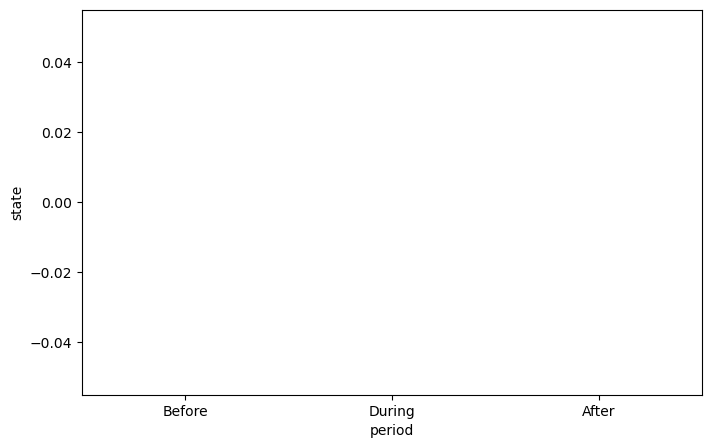

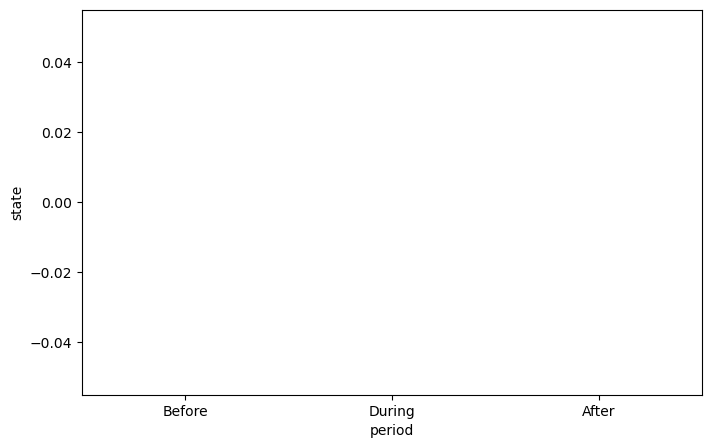

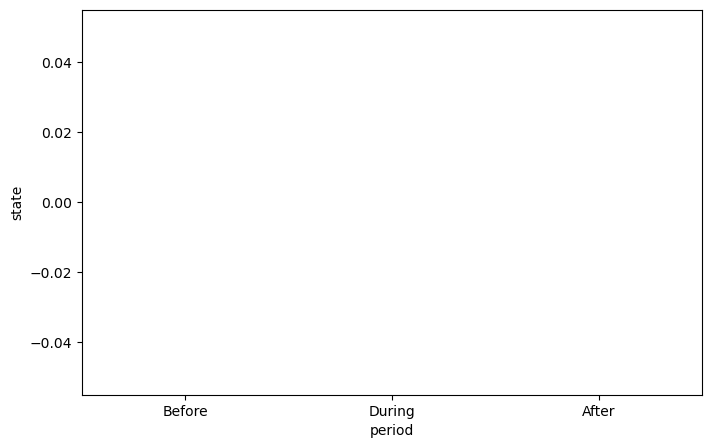

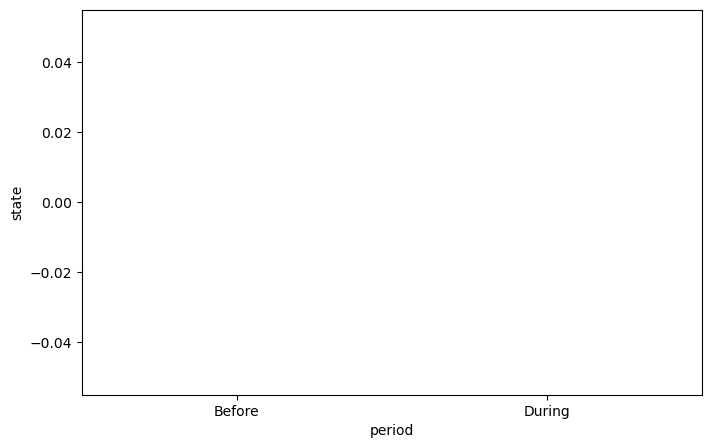

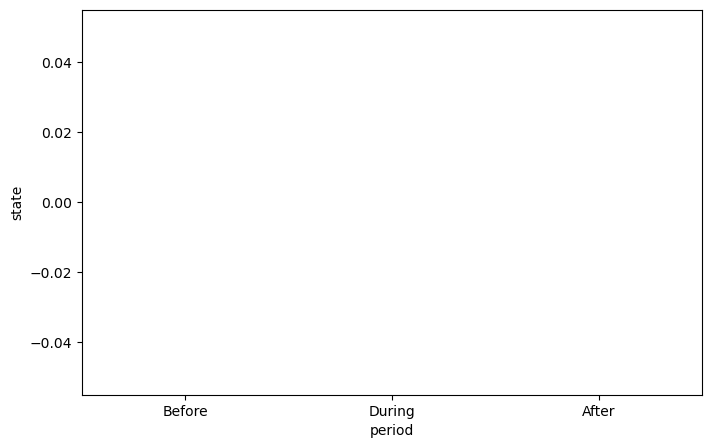

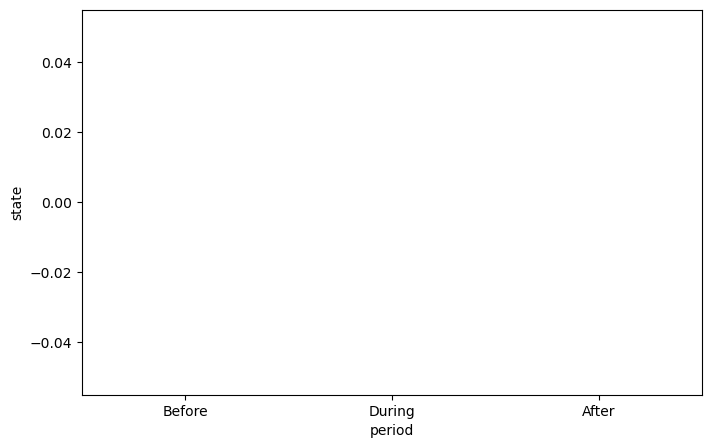

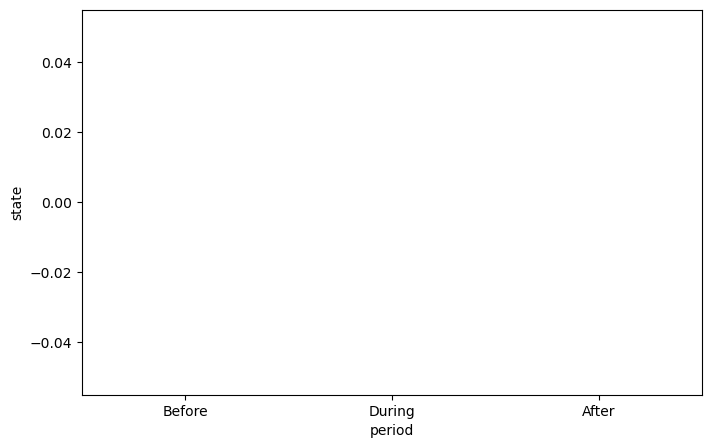

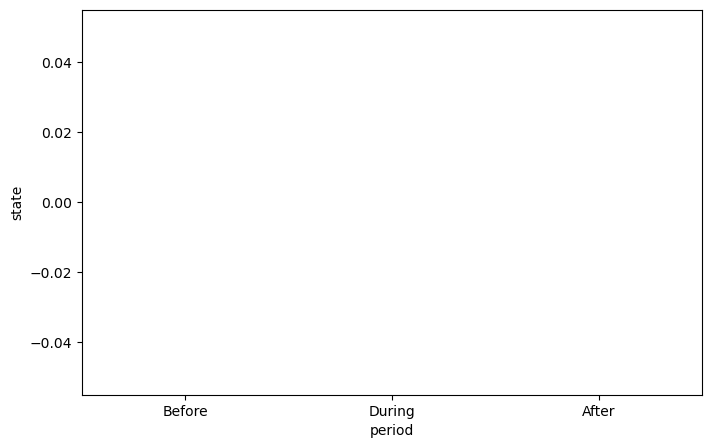

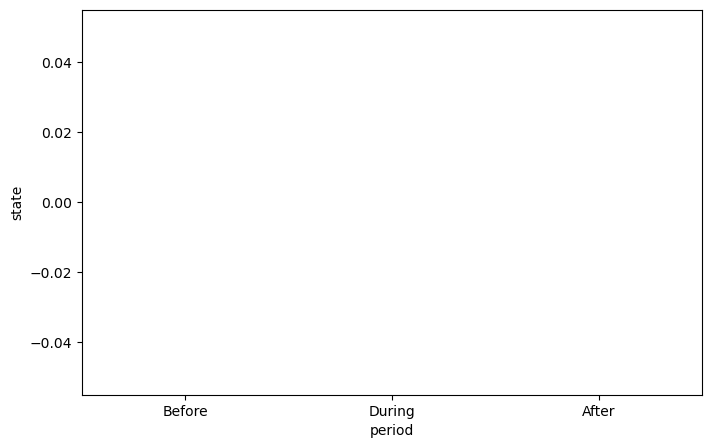

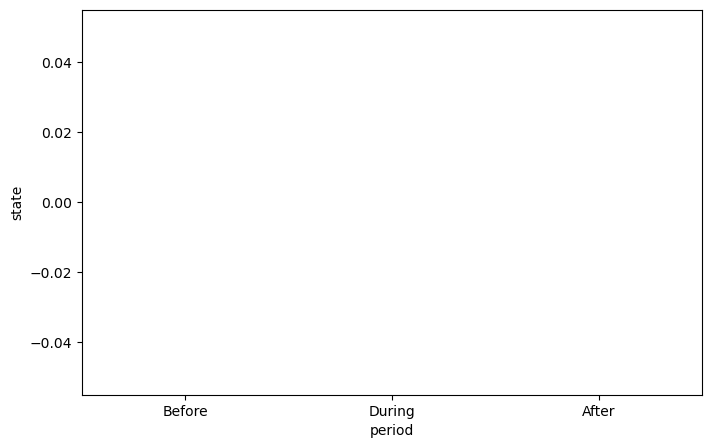

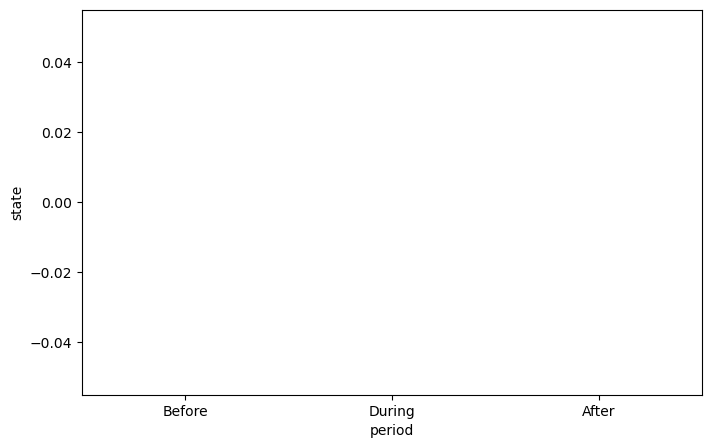

In [55]:
plot_and_save_all_measurements_from_directory(
    folder_path="/Users/jayashri/Desktop/ManualGranuleAnalysis_csvs",  # Path to your folder of CSV files
    start_sweep=11,                                      # Sweep number when drug starts being applied
    end_sweep=23,                                        # Sweep number when drug application ends
    sweep_duration=30                                    # Duration of each sweep in seconds
)

In [18]:
def plot_and_save_all_csvs_in_directory(
    folder_path, start_sweep, end_sweep, trace_column='trace', output_folder=None
):
    if output_folder is None:
        output_folder = os.path.join(folder_path, "drug_analysis_plots")
    os.makedirs(output_folder, exist_ok=True)

    # List all CSV files
    csv_files = [f for f in os.listdir(folder_path) if f.lower().endswith('.csv')]

    for csv_file in csv_files:
        csv_path = os.path.join(folder_path, csv_file)
        print(f"Processing: {csv_file}")
        
        try:
            df = pd.read_csv(csv_path)
            numeric_df = df.apply(pd.to_numeric, errors='coerce')
            numeric_df[trace_column] = df[trace_column]

            def label_period(trace_num):
                if trace_num < start_sweep:
                    return "Before"
                elif trace_num > end_sweep:
                    return "After"
                elif start_sweep < trace_num < end_sweep:
                    return "During"
                else:
                    return None

            numeric_df['period'] = numeric_df[trace_column].apply(label_period)
            filtered_df = numeric_df[numeric_df['period'].notna()]
            columns_to_plot = [
                col for col in filtered_df.columns
                if col not in [trace_column, 'period'] and filtered_df[col].dtype != 'O'
            ]

            for col in columns_to_plot:
                plt.figure(figsize=(8, 5))
                sns.stripplot(data=filtered_df, x='period', y=col, jitter=True, alpha=0.6)
                
                means = filtered_df.groupby('period')[col].mean()
                sems = filtered_df.groupby('period')[col].sem()
                plt.errorbar(x=means.index, y=means.values, yerr=sems.values, fmt='o', color='black', capsize=5, label='Mean ± SEM')
                
                plt.title(f'{col} by Drug Application Period')
                plt.ylabel(col)
                plt.xlabel('Condition')
                plt.grid(True, axis='y', linestyle='--', alpha=0.5)
                plt.tight_layout()
                plt.legend()

                # Save as PNG
                base_filename = os.path.splitext(csv_file)[0]
                png_filename = f"{base_filename}_{col}_drug_analysis.png"
                png_path = os.path.join(output_folder, png_filename)
                plt.savefig(png_path, dpi=300)
                plt.close()

            print(f"Saved plots for: {csv_file}")

        except Exception as e:
            print(f"Failed to process {csv_file}: {e}")

Processing: 25521006.csv
Failed to process 25521006.csv: [Errno 2] No such file or directory: '/Users/jayashri/Desktop/sEPSCsGranuleCell_300pM/drug_analysis_plots/25521006_max rise slope (pA/ms)_drug_analysis.png'
Processing: 25521012.csv
Failed to process 25521012.csv: [Errno 2] No such file or directory: '/Users/jayashri/Desktop/sEPSCsGranuleCell_300pM/drug_analysis_plots/25521012_max rise slope (pA/ms)_drug_analysis.png'
Processing: 25521002.csv
Failed to process 25521002.csv: [Errno 2] No such file or directory: '/Users/jayashri/Desktop/sEPSCsGranuleCell_300pM/drug_analysis_plots/25521002_max rise slope (pA/ms)_drug_analysis.png'
Processing: 25522003.csv
Failed to process 25522003.csv: [Errno 2] No such file or directory: '/Users/jayashri/Desktop/sEPSCsGranuleCell_300pM/drug_analysis_plots/25522003_max rise slope (pA/ms)_drug_analysis.png'


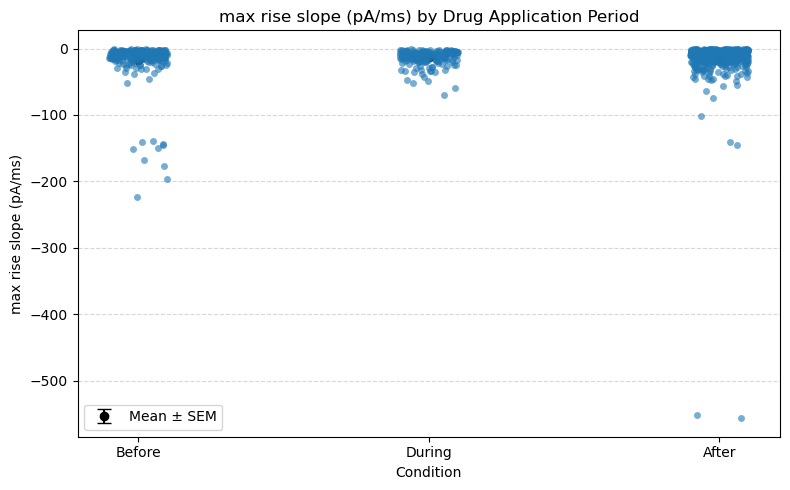

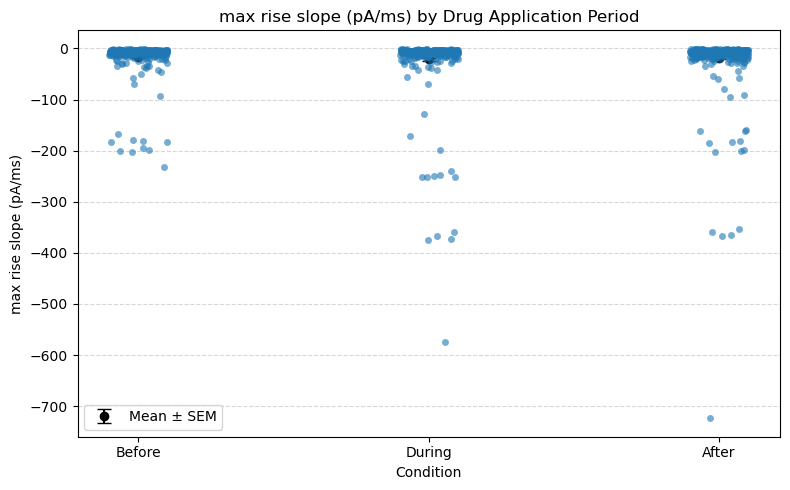

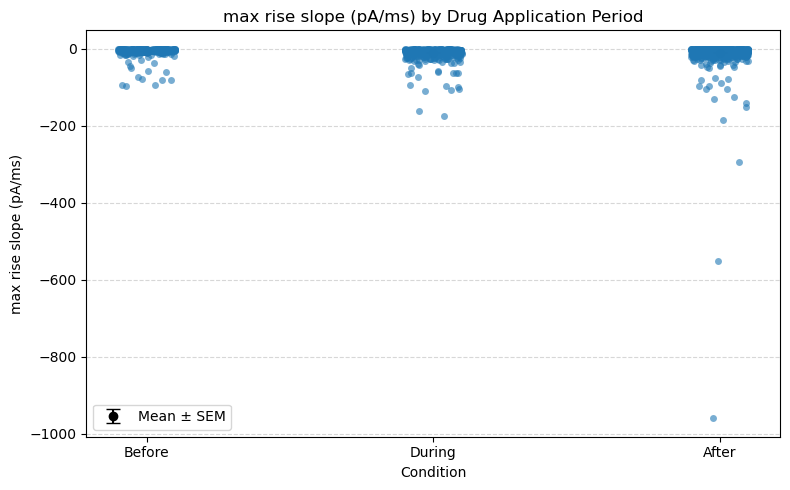

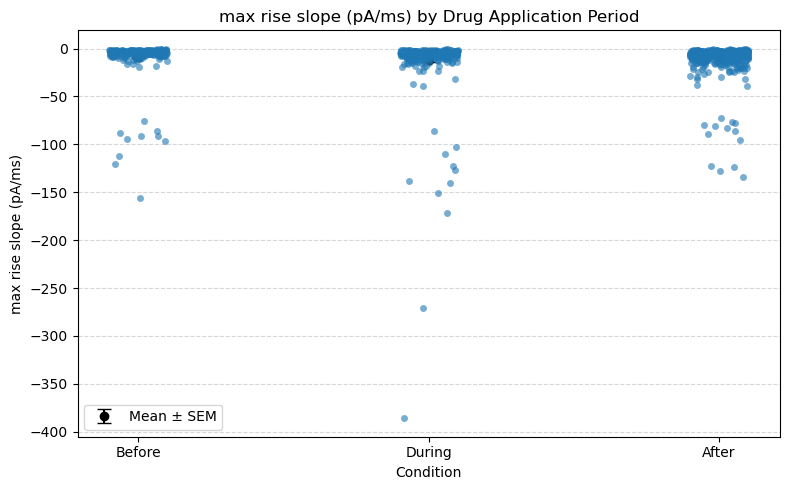

In [24]:
plot_and_save_all_csvs_in_directory(
    folder_path="/Users/jayashri/Desktop/sEPSCsGranuleCell_300pM",
    start_sweep=11,
    end_sweep=23
)